In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-03-30 10:03:23.412554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774865003.593302      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774865003.642476      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774865004.059695      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774865004.059738      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774865004.059741      55 computation_placer.cc:177] computation placer alr

/kaggle/input/datasets/aman2525/uwoc-520k/UWOC_520k_Dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/aman2525/uwoc-520k/UWOC_520k_Dataset.csv')

In [3]:
# 1. FEATURE ENGINEERING (Strictly matching the ML Champion Features!)
df['Symbol_Energy'] = (df['Feature_I']**2) + (df['Feature_Q']**2)
df['I_Q_Product'] = df['Feature_I'] * df['Feature_Q']

# We use the exact 7 features that won yesterday's Ablation Study
features = ['Feature_I', 'Feature_Q', 'Feature_Mag', 'Feature_Phase', 
            'ROP_Level', 'Symbol_Energy', 'I_Q_Product']

X = df[features].values
y = df['Label'].values

In [4]:
# 2. PREPROCESSING & EXACT STRATIFIED SPLIT
stratify_col = df['ROP_Level'].astype(str) + "_" + df['Label'].astype(str)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=stratify_col
)

# Scale the data (Fit on train, transform on test to prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# One-hot encode the labels for the CNN
y_train = to_categorical(y_train_raw, num_classes=16)
y_test = to_categorical(y_test_raw, num_classes=16)

# Reshape for 1D-CNN: [samples, features, 1 channel]
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Keep the unscaled ROP test values to filter for -28 dBm later
# ROP is at index 4 in our feature list
rop_test_values = X_test_raw[:, 4]
worst_rop = -28.0

print("Data preparation complete. Shapes and Stratification perfectly aligned with ML pipeline.")

Data preparation complete. Shapes and Stratification perfectly aligned with ML pipeline.


In [5]:
print(f"Training Shape: {X_train_cnn.shape}")
print(f"Testing Shape: {X_test_cnn.shape}")

Training Shape: (416000, 7, 1)
Testing Shape: (104000, 7, 1)


In [6]:
# =========================================================
# 3. 1D-CNN MODEL ARCHITECTURE
# =========================================================
model = Sequential([
    Input(shape=(7, 1)),
    
    # Block 1: Feature Extraction
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    
    # Block 2: Non-linear Pattern Recognition
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    
    Flatten(),
    
    # Dense Decision Head
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(16, activation='softmax') # Softmax for multi-class probability
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1774865028.165392      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774865028.171203      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
# =========================================================
# 4. TRAINING WITH EARLY STOPPING
# =========================================================
# Patience=5 means if accuracy doesn't improve for 5 epochs, stop to save time/prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Training Deep Learning Model ---")
history = model.fit(X_train_cnn, y_train, 
                    epochs=50, 
                    batch_size=1024, 
                    validation_split=0.2, 
                    callbacks=[early_stop], 
                    verbose=1)


--- Training Deep Learning Model ---
Epoch 1/50


I0000 00:00:1774865031.456526     126 service.cc:152] XLA service 0x1cebbd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774865031.456564     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774865031.456570     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774865031.895708     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


 30/325 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5106 - loss: 1.6142

I0000 00:00:1774865035.680846     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


325/325 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7460 - loss: 0.7569 - val_accuracy: 0.8071 - val_loss: 0.7198
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8124 - loss: 0.5117 - val_accuracy: 0.8227 - val_loss: 0.4751
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8143 - loss: 0.5023 - val_accuracy: 0.8232 - val_loss: 0.4718
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8172 - loss: 0.4944 - val_accuracy: 0.8246 - val_loss: 0.4705
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8179 - loss: 0.4921 - val_accuracy: 0.8246 - val_loss: 0.4695
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8199 - loss: 0.4858 - val_accuracy: 0.8237 - val_loss: 0.4702
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8217 - loss: 0.4839 - val_accuracy: 0.8251 - val_loss: 0.4696
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8186 - loss: 0.4890 - val_accuracy: 0.8258 - val_

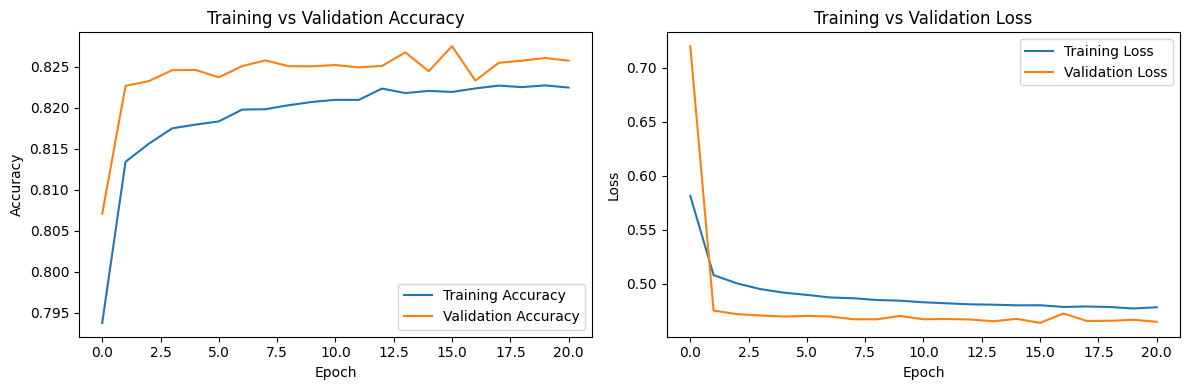

In [8]:
# =========================================================
# 5. PERFORMANCE VISUALIZATION (Loss/Accuracy Curves)
# =========================================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# =========================================================
# 6. CRITICAL ANALYSIS (-28 dBm FAILURE ZONE)
# =========================================================
print("\n--- Evaluating Failure Zone Performance ---")
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Extract ROP values from the 5th column (index 4) of our raw test split
rop_test_values = X_test_raw[:, 4] 
worst_rop = -28.0

# Mask for just the lowest power level
mask_28 = (rop_test_values == worst_rop)
acc_28 = accuracy_score(y_true[mask_28], y_pred[mask_28])


--- Evaluating Failure Zone Performance ---
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [12]:
print("\n" + "="*50)
print(f"FINAL OVERALL MODEL ACCURACY: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"ACCURACY AT CRITICAL ROP ({worst_rop} dBm): {acc_28*100:.2f}%")
print("="*50)


FINAL OVERALL MODEL ACCURACY: 82.80%
ACCURACY AT CRITICAL ROP (-28.0 dBm): 71.46%


In [13]:
# =========================================================
# 1. ADVANCED MODEL ARCHITECTURE (ResNet + Attention)
# =========================================================


from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten, Dropout, BatchNormalization, Add, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
def build_advanced_model(input_shape):
    # Input layer for our 7 features
    inputs = Input(shape=input_shape)
    
    # --- Block 1: Initial Feature Extraction ---
    # Using 'swish' activation as it often outperforms ReLU in deep communication networks
    x = Conv1D(64, kernel_size=3, padding='same', activation='swish')(inputs)
    x = BatchNormalization()(x)
    
    # --- Block 2: Residual Block (Skip Connection) ---
    # This prevents the "Vanishing Gradient" problem at low ROP levels
    shortcut = x
    x = Conv1D(64, kernel_size=3, padding='same', activation='swish')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut]) # Merging raw feature maps with learned maps
    
    # --- Block 3: Multi-Head Self-Attention ---
    # This weighs the 7 features (I, Q, Mag, Phase, ROP, Energy, Ratio) 
    # based on their importance in the current noise environment
    att_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = Add()([x, att_output])
    x = LayerNormalization()(x)
    
    # --- Block 4: Flatten & Decision Head ---
    x = Flatten()(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.4)(x) # Higher dropout to fight the 520k-sample overfitting
    x = Dense(128, activation='swish')(x)
    
    outputs = Dense(16, activation='softmax')(x)
    
    return Model(inputs, outputs)

# Initialize the model
advanced_model = build_advanced_model((7, 1))

# Using a slightly lower learning rate with a Scheduler for stability
advanced_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [14]:
# =========================================================
# 2. TRAINING STRATEGY
# =========================================================
# ReduceLROnPlateau: Automatically shrinks the learning rate when accuracy plateaus
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\n--- Training Advanced Res-Attention Model ---")
history_adv = advanced_model.fit(
    X_train_cnn, y_train, 
    epochs=100, # Increased epochs because LR-scheduler will manage the time
    batch_size=512, # Smaller batch size for better stochastic gradient descent
    validation_split=0.2, 
    callbacks=[early_stop, lr_reducer], 
    verbose=1
)


--- Training Advanced Res-Attention Model ---
Epoch 1/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7435 - loss: 0.7408 - val_accuracy: 0.8238 - val_loss: 0.4736 - learning_rate: 5.0000e-04
Epoch 2/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8159 - loss: 0.4969 - val_accuracy: 0.8238 - val_loss: 0.4713 - learning_rate: 5.0000e-04
Epoch 3/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8173 - loss: 0.4951 - val_accuracy: 0.8254 - val_loss: 0.4670 - learning_rate: 5.0000e-04
Epoch 4/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8186 - loss: 0.4889 - val_accuracy: 0.8254 - val_loss: 0.4651 - learning_rate: 5.0000e-04
Epoch 5/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8187 - loss: 0.4867 - val_accuracy: 0.8258 - val_loss: 0.4675 - learning_rate: 5.0000e-04
Epoch 6/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8198 - loss: 0.4845 - val_accuracy: 0.8252 - val_loss: 0.4643 - learning_rate: 5.0000e-04
Epoch 7/10

In [16]:
# =========================================================
# 3. COMPARATIVE EVALUATION (-28 dBm)
# =========================================================
print("\n--- Evaluating Advanced Model Performance ---")
y_pred_probs_adv = advanced_model.predict(X_test_cnn)
y_pred_adv = np.argmax(y_pred_probs_adv, axis=1)
y_true_adv = np.argmax(y_test, axis=1)

# Filter for -28 dBm level using the raw_X_test we kept earlier
rop_test_values = X_test_raw[:, 4] 
worst_rop = -28.0
mask_28 = (rop_test_values == worst_rop)

acc_28_adv = accuracy_score(y_true_adv[mask_28], y_pred_adv[mask_28])
overall_acc_adv = accuracy_score(y_true_adv, y_pred_adv)

print("\n" + "="*50)
print(f"OLD MODEL ACCURACY @ -28 dBm: 71.88%") 
print(f"NEW ADVANCED MODEL ACCURACY @ -28 dBm: {acc_28_adv*100:.2f}%")
print(f"NEW OVERALL MODEL ACCURACY: {overall_acc_adv*100:.2f}%")
print("="*50)


--- Evaluating Advanced Model Performance ---
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

OLD MODEL ACCURACY @ -28 dBm: 71.88%
NEW ADVANCED MODEL ACCURACY @ -28 dBm: 72.11%
NEW OVERALL MODEL ACCURACY: 83.06%


In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# =========================================================
# FINAL EXTRACTION: SAVE DEEP LEARNING RESULTS TO CSV
# =========================================================
print("--- Extracting and Saving DL Curves ---")

# 1. Get the unique power levels, sorted from -22 down to -28
rop_levels_unique = np.sort(np.unique(rop_test_values))[::-1] 

basic_cnn_accuracies = []
advanced_cnn_accuracies = []

# 2. Predict on the entire test set using BOTH models
print("Generating predictions...")
y_pred_basic = np.argmax(model.predict(X_test_cnn), axis=1)
y_pred_adv = np.argmax(advanced_model.predict(X_test_cnn), axis=1)
y_true = np.argmax(y_test, axis=1)

# 3. Loop through each specific power level to get the exact curves
for r in rop_levels_unique:
    mask_r = (rop_test_values == r)
    
    # Calculate accuracy for Basic CNN at this power level
    acc_basic = accuracy_score(y_true[mask_r], y_pred_basic[mask_r])
    basic_cnn_accuracies.append(acc_basic)
    
    # Calculate accuracy for Advanced CNN at this power level
    acc_adv = accuracy_score(y_true[mask_r], y_pred_adv[mask_r])
    advanced_cnn_accuracies.append(acc_adv)

# 4. Save the compiled data to a new CSV file
dl_export_df = pd.DataFrame({
    'ROP_Level': rop_levels_unique,
    'Basic_CNN_Accuracy': basic_cnn_accuracies,
    'Advanced_CNN_Accuracy': advanced_cnn_accuracies
})

dl_export_df.to_csv('DL_Results_For_Graph.csv', index=False)

print("\n" + "="*60)
print("SUCCESS: Deep Learning results saved to 'DL_Results_For_Graph.csv'.")
print("Your ML data and DL data are now perfectly secured in two CSV files.")
print("="*60)

--- Extracting and Saving DL Curves ---
Generating predictions...
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

SUCCESS: Deep Learning results saved to 'DL_Results_For_Graph.csv'.
Your ML data and DL data are now perfectly secured in two CSV files.
